# [실습1] 한국어 영화 리뷰 분석 및 시각화

## 📚 실습 목표

이 실습에서는 한국어 텍스트 데이터 처리의 **전체 파이프라인**을 이해하고 구현합니다:

1. **데이터 전처리** — 정규표현식으로 한글 텍스트 정제
2. **자연어 처리** — 형태소 분석기(Okt)로 의미 있는 단어 추출
3. **데이터 시각화** — 분석 결과를 다양한 방식으로 표현

## 🔄 처리 파이프라인

```
[입력 텍스트] 
    ↓
[정규표현식으로 한글만 추출]
    ↓
[형태소 분석 + 품사 필터링]
    ↓
[불용어 제거]
    ↓
[단어 빈도 집계]
    ↓
[BarPlot, WordCloud 시각화]
```

## 📖 핵심 개념

- **형태소(Morpheme)**: 의미를 가진 가장 작은 단위의 말 (e.g., "영화" = 1개 형태소, "봤어" = "보" + "았" + "어" 3개)
- **품사(Part of Speech)**: 명사, 동사, 형용사 등 단어의 문법적 역할
- **불용어(Stopword)**: 분석에 의미가 없는 조사, 접미사, 과도하게 흔한 단어들


## 📝 과제 안내

이 노트북은 **실습 과제용**입니다. 아래 3곳에 `# TODO` 표시와 단계별 힌트만 남기고 구현을 비워두었습니다.

1. `load_corpus()` — ① 입력 파일 로드 및 전처리
2. `tokenize_and_count()` — ② 형태소 분석 + 필터링
3. `plot_barplot_wordcloud()` — ④ 시각화: BarPlot + WordCloud

세 함수 모두 **docstring과 함수 시그니처는 그대로 유지**되어 있으니, 힌트 주석을 따라 함수 본문만 채우면 됩니다. 하나를 채워야 이어지는 셀(불용어 필터·개선 분석·고급 시각화 등)이 정상 동작합니다.

In [15]:
%pip install konlpy
%pip install koreanize_matplotlib
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
%pip install konlpy koreanize_matplotlib wordcloud pillow -q

from konlpy.tag import Okt
from collections import Counter
from wordcloud import WordCloud
from pathlib import Path
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from PIL import Image
import platform

# 한글 폰트 설정 (koreanize_matplotlib 사용)
import koreanize_matplotlib

warnings.filterwarnings('ignore')


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
# ==================== 하이퍼파라미터 설정 ====================

# 분석 관련 설정
TOP_N = 40  # 상위 N개 단어 표시
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# 데이터 파일 경로
data_dir = Path("data")
in_file = data_dir / "input.txt"
img_file = Path("elice.png")

# 한글 폰트 설정
# koreanize_matplotlib는 matplotlib(BarPlot 등) 한글 폰트만 자동으로 처리합니다.
# WordCloud는 별도 라이브러리라 자동 적용되지 않으므로, 시스템별 한글 폰트 경로를
# 직접 탐색해 FONT_PATH로 지정합니다. (못 찾으면 None -> WordCloud 한글이 깨질 수 있음)
_FONT_CANDIDATES = {
    "Windows": ["C:/Windows/Fonts/malgun.ttf"],
    "Darwin": ["/System/Library/Fonts/AppleGothic.ttf", "/System/Library/Fonts/Supplemental/AppleGothic.ttf"],
    "Linux": [
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    ],
}

FONT_PATH = None
for _candidate in _FONT_CANDIDATES.get(platform.system(), []):
    if Path(_candidate).exists():
        FONT_PATH = _candidate
        break

if FONT_PATH is None:
    warnings.warn("한글 폰트를 찾지 못했습니다. WordCloud에서 한글이 깨져 보일 수 있습니다.")


## ① 입력 파일 로드 및 전처리

### 왜 전처리가 필요한가?

자연어 데이터는 다양한 형식(숫자, 특수문자, 이모지 등)을 포함하고 있습니다. 분석 목표에 맞게 **불필요한 정보를 제거**하는 과정이 전처리입니다.

### 정규표현식(Regex)으로 한글만 추출

- `[^가-힣\s]`: 한글(**가**부터 **힣**까지)과 공백(**\s**)을 제외한 모든 문자 제거
- 결과: 한글 텍스트만 남아 형태소 분석에 집중 가능


In [18]:
# ==================== 함수 1: 코퍼스 로드 및 전처리 ====================

def load_corpus(file_path: Path) -> list[str]:
    """
    파일에서 문장을 로드하고 정규표현식으로 한글만 추출합니다.

    Args:
        file_path (Path): 입력 파일 경로

    Returns:
        list[str]: 전처리된 문장 리스트
    """
    if not file_path.exists():
        warnings.warn(f"입력 파일을 찾을 수 없습니다: {file_path}. 샘플 문장으로 대체합니다.")
        return [
            "이 영화 정말 감동적이었어요",
            "연기가 최고였어",
            "너무 재미있었다",
            "시간이 빨리 갔어",
            "정말 추천합니다",
        ]

    sentences = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            cleaned = re.sub(r"[^가-힣\s]", " ", line).strip()
            if cleaned:
                sentences.append(cleaned)

    return sentences

# 데이터 로드
corpus = load_corpus(in_file)

## ② 형태소 분석 + 필터링

### 형태소 분석이란?

문장을 의미 있는 최소 단위(형태소)로 분리하고 각각의 **품사(품사 태그)**를 부여합니다.

**예시:**
- 입력: "이 영화는 정말 감동적이었어"
- 출력: [('이', 'Determiner'), ('영화', 'Noun'), ('는', 'Josa'), ('정말', 'Adverb'), ('감동적이', 'Adjective'), ('었', 'Suffix'), ('어', 'Ending')]

### 품사 필터링의 중요성

모든 품사가 분석에 중요하지는 않습니다:
- **✅ 유지:** 명사(Noun), 동사(Verb), 형용사(Adjective) — 의미 있는 단어
- **❌ 제거:** 조사(Josa), 접미사(Suffix), 구두점(Punctuation) — 문법 요소

**Okt 품사 태그 일부:**
| 태그 | 의미 | 예시 |
|------|------|------|
| Noun | 명사 | 영화, 감동 |
| Verb | 동사 | 보다, 하다 |
| Adjective | 형용사 | 재미있다, 좋다 |
| Josa | 조사 | 는, 이, 을 |
| Suffix | 접미사 | ~성, ~적 |
| Punctuation | 구두점 | 。, ？ |


In [19]:
# ==================== 함수 2: 형태소 분석 + 불용어 필터 ====================

def tokenize_and_count(
    sentences: list[str],
    okt: Okt,
    stopwords: set,
    allowed_pos: set = {"Noun", "Verb", "Adjective"},
    min_length: int = 2,
    min_freq: int = 1
) -> Counter:
    """
    문장 리스트를 형태소로 분석하고, 불용어를 제거한 뒤 빈도를 계산합니다.

    Args:
        sentences: 입력 문장 리스트
        okt: Okt 형태소 분석기
        stopwords: 제거할 불용어 집합
        allowed_pos: 유지할 품사 집합 (기본값: 명사, 동사, 형용사)
        min_length: 최소 단어 길이
        min_freq: 최소 빈도 (후처리 단계에서 필터)

    Returns:
        Counter: {단어: 빈도} 형식의 Counter 객체
    """
    tokens = []
    for sent in sentences:
        for morpheme, pos in okt.pos(sent):
            if pos not in allowed_pos:
                continue
            if morpheme in stopwords:
                continue
            if len(morpheme) < min_length:
                continue
            tokens.append(morpheme)

    return Counter(tokens)

# 기본 불용어 설정
BASIC_STOPWORDS = {
    "영화", "정말", "진짜", "평점", "너무",  # 영화 리뷰 특화 불용어
    "하다", "되다", "있다", "없다",  # 빈도 높은 동사
    "좋다", "나쁘다", "크다", "작다",  # 빈도 높은 형용사
}

# 형태소 분석 수행
print("[Step 1] 형태소 분석 중...")
okt = Okt()
counter = tokenize_and_count(corpus, okt, BASIC_STOPWORDS)

# 상위 20개 조회 (탐색용)
print("\n[상위 20개 토큰]")
for word, freq in counter.most_common(20):
    print(f"  {word:15} {freq:6,}")

[Step 1] 형태소 분석 중...

[상위 20개 토큰]
  연기               1,129
  최고               1,059
  스토리                914
  생각                 886
  감동                 858
  드라마                855
  사람                 852
  보고                 845
  하는                 822
  감독                 728
  재미                 717
  시간                 714
  그냥                 682
  내용                 673
  배우                 656
  이런                 640
  없는                 606
  쓰레기                585
  작품                 550
  하나                 540


### 참고: 기본 분석 결과의 문제점

위의 상위 20개 결과를 보면 **조사(이, 점)와 의존명사(점)**가 상위권을 차지합니다.  
이는 우리가 원하는 **의미 있는 단어**가 아닙니다. 다음 섹션의 "개선된 분석"에서  
더 정교한 불용어 필터를 적용하여 이 문제를 해결합니다.


## ③ 상위 단어 목록 저장

### 불용어(Stopword)란?

분석 목표에 기여하지 않는 단어들을 제거하는 프로세스입니다:
- 한국어 조사: 은, 는, 을, 를, 에, 에서...
- 영화 리뷰에서 과도하게 반복되는 표현: 영화, 정말, 진짜, 평점
- 너무 일반적인 동사/형용사: 하다, 되다, 좋다, 나쁘다

**효과:** 불용어 제거 후 의미 있는 단어(영화 감정, 배우 연기, 스토리 평가)가 두드러집니다.


In [20]:
# ==================== 함수 3: 상위 N개 단어 저장 ====================

def save_top_tokens(counter: Counter, top_n: int, output_path: Path) -> None:
    """상위 N개 단어를 텍스트 파일로 저장합니다."""
    output_path.parent.mkdir(exist_ok=True, parents=True)
    
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write("단어\t빈도\t백분율\n")
        f.write("=" * 40 + "\n")
        
        total = sum(counter.values())
        for i, (word, freq) in enumerate(counter.most_common(top_n), 1):
            percentage = (freq / total) * 100
            f.write(f"{i:3d}. {word:15} {freq:6,} ({percentage:5.2f}%)\n")
    
    print(f"✓ 저장됨: {output_path}")

# 상위 40개 저장
save_top_tokens(counter, TOP_N, OUTPUT_DIR / "basic_top_tokens.txt")


✓ 저장됨: output\basic_top_tokens.txt


## ④ 시각화: BarPlot + WordCloud

### 각 시각화 방식의 특징

**BarPlot (막대 그래프)**
- ✅ 정확한 빈도 수치 비교 가능
- ✅ 상위 N개 단어 순서 명확
- ❌ 많은 단어를 한눈에 보기 어려움

**WordCloud (워드클라우드)**
- ✅ 시각적 임팩트가 강함
- ✅ 단어 크기로 직관적 이해 가능
- ❌ 정확한 수치 파악 어려움
- ❌ 작은 단어들 가독성 떨어짐

→ **두 가지를 함께 사용**하여 정량 분석과 시각적 인사이트를 모두 확보합니다.


[Step 2] 시각화 중...


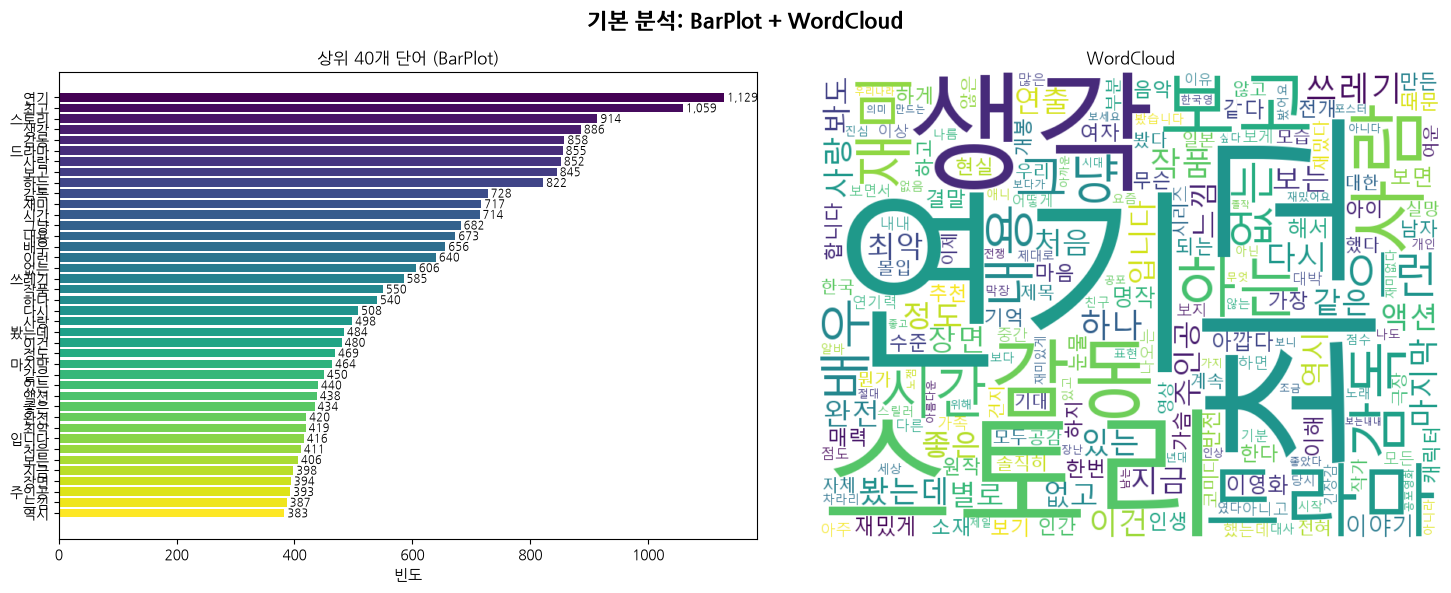

✓ 저장됨: output\기본_분석_BarPlot_+_WordCloud.png


In [21]:
# ==================== 함수 4: BarPlot + WordCloud 시각화 ====================

def plot_barplot_wordcloud(
    counter: Counter,
    top_n: int,
    # font_path: str,  # koreanize_matplotlib이 자동 처리
    title: str,
    mask_path: Path = None
) -> None:
    """
    상위 N개 단어를 BarPlot과 WordCloud로 시각화합니다.

    Args:
        counter: 단어 빈도 Counter
        top_n: 표시할 상위 N개
        font_path: 한글 폰트 경로
        title: 그래프 제목
        mask_path: WordCloud 마스크 이미지 경로 (선택사항)
    """
    top_items = counter.most_common(top_n)
    words = [word for word, _ in top_items]
    freqs = [freq for _, freq in top_items]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # [왼쪽] BarPlot
    ax1 = axes[0]
    y_pos = range(len(words))
    ax1.barh(y_pos, freqs, color=plt.cm.viridis(np.linspace(0, 1, len(words))))
    ax1.set_yticks(list(y_pos))
    ax1.set_yticklabels(words)
    ax1.invert_yaxis()
    ax1.set_xlabel('빈도', fontsize=11)
    ax1.set_title(f'상위 {top_n}개 단어 (BarPlot)', fontsize=12)
    for i, freq in enumerate(freqs):
        ax1.text(freq, i, f' {freq:,}', va='center', fontsize=8)

    # [오른쪽] WordCloud
    ax2 = axes[1]
    mask_array = None
    if mask_path is not None and Path(mask_path).exists():
        mask_array = np.array(Image.open(mask_path))

    wc = WordCloud(
        font_path=FONT_PATH,
        background_color='white',
        mask=mask_array,
        width=800,
        height=600,
    ).generate_from_frequencies(counter)

    ax2.imshow(wc, interpolation='bilinear')
    ax2.axis('off')
    ax2.set_title('WordCloud', fontsize=12)

    plt.tight_layout()
    # 파일 시스템에서 쓸 수 없는 문자(: \ / 등)를 제거해 안전한 파일명을 만듭니다
    safe_name = re.sub(r'[\\/:*?"<>|]', '', title).replace(' ', '_')
    save_path = OUTPUT_DIR / f"{safe_name}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ 저장됨: {save_path}")

# 기본 분석 시각화
print("[Step 2] 시각화 중...")
plot_barplot_wordcloud(counter, TOP_N, "기본 분석: BarPlot + WordCloud")

## ⑤ 기본 분석 결과 요약

기본 분석(불용어 최소 필터)의 문제점:
- 조사(이, 점, 는)가 상위권 차지
- 의존명사(점)의 중복 집계
- 동사 어미 변형 형태(보는/봐도/봤어)가 각각 집계됨

→ 다음 섹션에서 **더 강화된 불용어 필터**를 적용합니다.


In [22]:
# ==================== 기본 분석 통계 ====================

print("=" * 60)
print("[기본 분석 결과 요약]")
print("=" * 60)
total_tokens = sum(counter.values())
unique_tokens = len(counter)

print(f"총 토큰 수: {total_tokens:,}개")
print(f"고유 단어 수: {unique_tokens:,}개")
print(f"평균 빈도: {total_tokens / unique_tokens:.2f}")
print(f"최고 빈도: {counter.most_common(1)[0][1]:,}개 ('{counter.most_common(1)[0][0]}')")
print("=" * 60)


[기본 분석 결과 요약]
총 토큰 수: 180,918개
고유 단어 수: 34,530개
평균 빈도: 5.24
최고 빈도: 1,129개 ('연기')


## ⭐ 개선된 분석: 더 의미 있는 단어 추출

기본 분석의 문제점을 해결하기 위해 다음을 적용합니다:

1. **확장된 불용어 필터** — 조사, 접미사, 영화 리뷰 상투어 추가
2. **품사 필터 강화** — 명사/동사/형용사 3가지만 허용 (조사/접미사 완전 제외)
3. **길이 필터** — 1글자 단어 제거
4. **빈도 필터** — 5회 미만의 희귀 단어 제거

**기대 효과:** 의미 있는 영화평가 표현(감동, 연기, 재미 등)이 명확하게 드러남


In [23]:
# ==================== 개선된 불용어 필터 ====================

IMPROVED_STOPWORDS = {
    # 조사 (완전 제거)
    "이", "의", "가", "를", "을", "인", "한", "는", "고", "며", "로", 
    "와", "으로", "같이", "에서", "마다", "부터", "까지", "만", "면", "듯",
    
    # 접미사 (완전 제거)
    "적", "성", "적", "함", "음", "이", "인", "하", "어", "았",
    
    # 영화 리뷰 상투어
    "영화", "정말", "진짜", "평점", "너무", "아주", "매우", "그냥",
    "이", "것", "분", "점", "번", "중",  # 의존명사
    
    # 빈도 높은 동사/형용사 (부분 제거 — 원형만 유지)
    "하", "되", "있", "없", "않",  # 조동사/부정사
    "있다", "없다", "되다", "하다",
    "같다", "다르다", "좋다", "나쁘다",
    
    # 부사
    "매우", "정말", "아주", "그냥", "거의", "완전", "뭔가",
}

print("[Step 3] 개선된 필터 적용 중...")
MIN_FREQ = 5  # 5회 미만 단어 제거
improved_counter = tokenize_and_count(
    corpus,
    okt,
    IMPROVED_STOPWORDS,
    min_length=2,
    min_freq=MIN_FREQ
)
# tokenize_and_count는 min_freq를 카운트에 반영하지 않으므로 여기서 후처리로 적용합니다
improved_counter = Counter({word: freq for word, freq in improved_counter.items() if freq >= MIN_FREQ})

print("\n[상위 30개 개선 분석 결과]")
for word, freq in improved_counter.most_common(30):
    print(f"  {word:15} {freq:6,}")

# 개선된 결과 저장
save_top_tokens(improved_counter, TOP_N, OUTPUT_DIR / "improved_top_tokens.txt")


[Step 3] 개선된 필터 적용 중...

[상위 30개 개선 분석 결과]
  연기               1,129
  최고               1,059
  스토리                914
  생각                 886
  감동                 858
  드라마                855
  사람                 852
  보고                 845
  하는                 822
  감독                 728
  재미                 717
  시간                 714
  내용                 673
  배우                 656
  이런                 640
  없는                 606
  쓰레기                585
  작품                 550
  하나                 540
  다시                 508
  사랑                 498
  봤는데                484
  이건                 480
  정도                 469
  마지막                464
  같은                 450
  있는                 440
  액션                 438
  좋은                 434
  최악                 419
✓ 저장됨: output\improved_top_tokens.txt


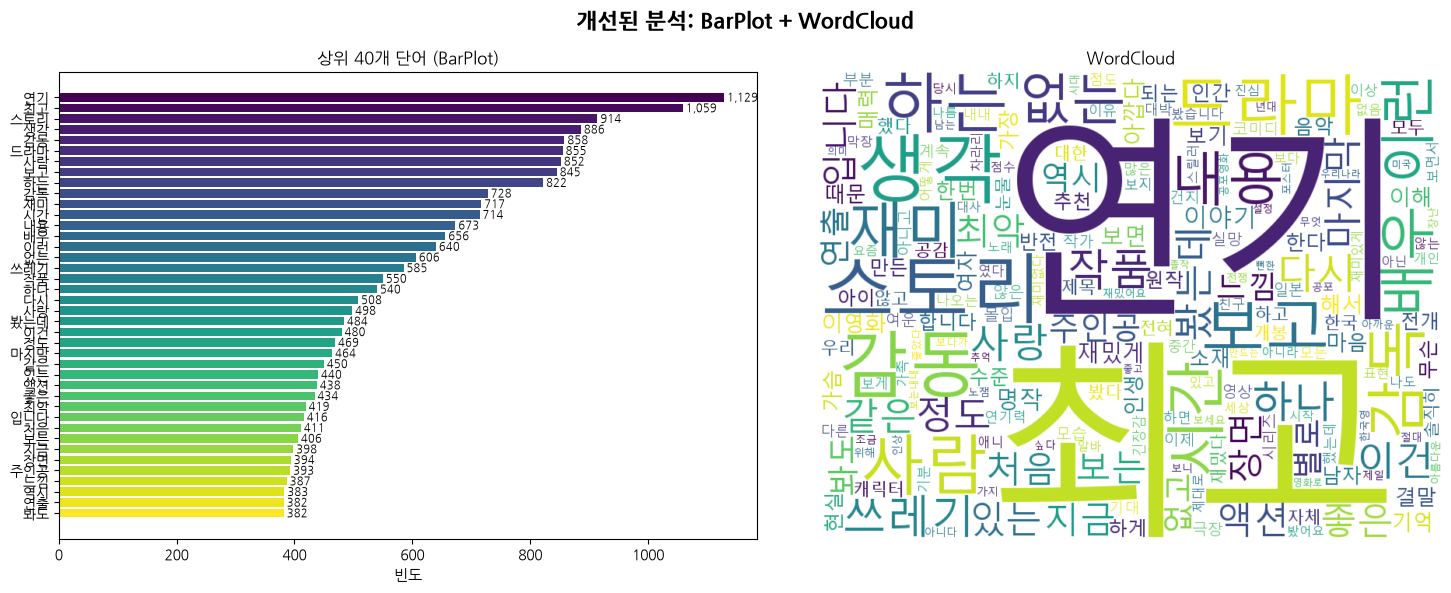

✓ 저장됨: output\개선된_분석_BarPlot_+_WordCloud.png

[비교 분석]
기본 분석 고유 단어: 34,530개
개선 분석 고유 단어: 5,465개
감소율: 84.2%


In [24]:
# 개선된 분석 시각화
plot_barplot_wordcloud(
    improved_counter,
    TOP_N,
    "개선된 분석: BarPlot + WordCloud",
    mask_path=img_file
)

# 비교 분석: 기본 vs 개선
print("\n[비교 분석]")
print(f"기본 분석 고유 단어: {len(counter):,}개")
print(f"개선 분석 고유 단어: {len(improved_counter):,}개")
print(f"감소율: {(1 - len(improved_counter)/len(counter))*100:.1f}%")

## 📊 고급 시각화: 더 깊이 있는 분석

단순히 상위 N개를 보는 것보다 더 유용한 통계 시각화 방법들입니다.

각 그래프가 드러내는 인사이트:
1. **히스토그램** — 전체 단어의 빈도 분포 형태
2. **누적 선 그래프** — 상위 몇 % 단어가 전체 빈도의 몇 %를 차지하는가?
3. **박스플롯** — 이상치(매우 빈도 높은 단어)와 일반적인 범위 파악
4. **데이터 통계표** — 정량적 요약 (평균, 중앙값, 표준편차 등)


In [25]:
# ==================== 고급 분석 1: 통계 테이블 ====================

print("[고급 분석 1] 통계 테이블 생성 중...")

# DataFrame으로 통계 정보 생성
top_50 = improved_counter.most_common(50)
df_stats = pd.DataFrame(top_50, columns=['단어', '빈도'])

# 백분율 계산
total = improved_counter.total() if hasattr(improved_counter, 'total') else sum(improved_counter.values())
df_stats['누적백분율'] = df_stats['빈도'].cumsum() / total * 100

print("\n[상위 50개 단어 통계]")
print(df_stats.to_string(index=False))
print(f"\n참고: 상위 50개가 전체 빈도의 {df_stats.iloc[-1]['누적백분율']:.1f}% 차지")


[고급 분석 1] 통계 테이블 생성 중...

[상위 50개 단어 통계]
 단어   빈도     누적백분율
 연기 1129  0.827646
 최고 1059  1.603976
스토리  914  2.274010
 생각  886  2.923518
 감동  858  3.552499
드라마  855  4.179282
 사람  852  4.803865
 보고  845  5.423316
 하는  822  6.025907
 감독  728  6.559588
 재미  717  7.085206
 시간  714  7.608624
 내용  673  8.101986
 배우  656  8.582886
 이런  640  9.052056
 없는  606  9.496302
쓰레기  585  9.925153
 작품  550 10.328346
 하나  540 10.724208
 다시  508 11.096612
 사랑  498 11.461686
봤는데  484 11.816496
 이건  480 12.168374
 정도  469 12.512187
마지막  464 12.852336
 같은  450 13.182221
 있는  440 13.504776
 액션  438 13.825864
 좋은  434 14.144021
 최악  419 14.451181
입니다  416 14.756141
 처음  411 15.057437
 보는  406 15.355067
 지금  398 15.646832
 장면  394 15.935665
주인공  393 16.223765
 느낌  387 16.507466
 역시  383 16.788236
 연출  382 17.068272
 봐도  382 17.348308
 없고  378 17.625411
 별로  375 17.900316
이야기  373 18.173754
 명작  360 18.437663
 보면  336 18.683977
재밌게  318 18.917096
아깝다  316 19.148749
이영화  305 19.372338
 이해  301 19.592995
 해서  300 

[고급 분석 2] 시각화 중...
✓ 저장됨: output\advanced_analysis_grid.png


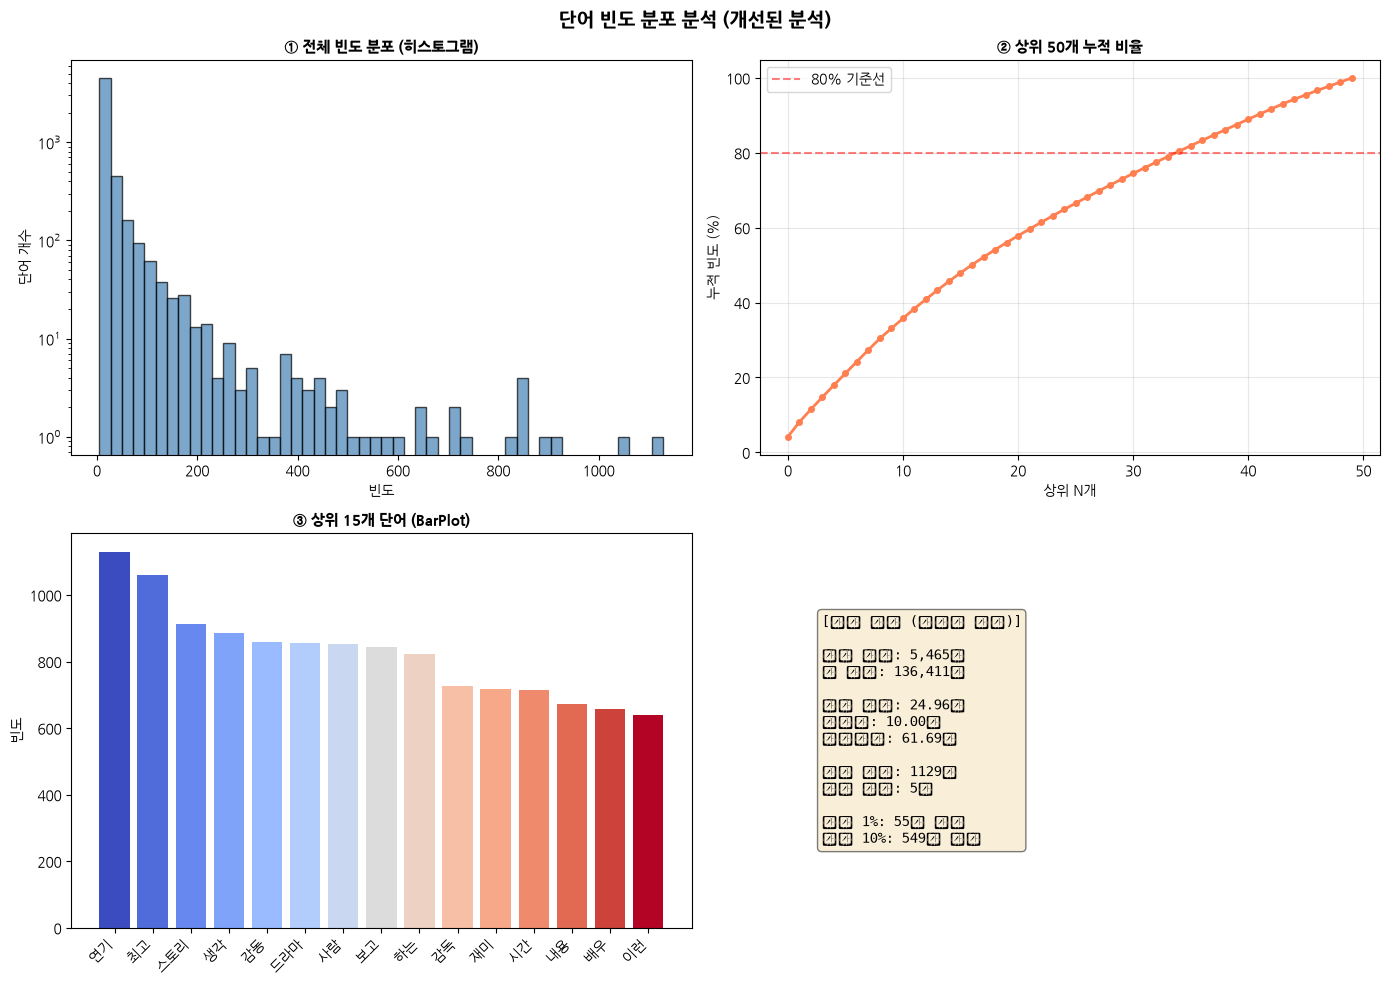

In [26]:
# ==================== 고급 분석 2: 분포 시각화 (2x2 그리드) ====================

print("[고급 분석 2] 시각화 중...")

# 빈도 배열 생성
all_frequencies = [count for word, count in improved_counter.most_common()]
top_50_frequencies = [count for word, count in improved_counter.most_common(50)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('단어 빈도 분포 분석 (개선된 분석)', fontsize=14, fontweight='bold')

# [1-1] 히스토그램
ax = axes[0, 0]
ax.hist(all_frequencies, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('빈도', fontsize=10)
ax.set_ylabel('단어 개수', fontsize=10)
ax.set_title('① 전체 빈도 분포 (히스토그램)', fontsize=11, fontweight='bold')
ax.set_yscale('log')

# [1-2] 누적 비율 선 그래프
ax = axes[0, 1]
cumsum_freqs = np.cumsum(top_50_frequencies) / sum(top_50_frequencies) * 100
ax.plot(range(len(cumsum_freqs)), cumsum_freqs, 'o-', linewidth=2, markersize=4, color='coral')
ax.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% 기준선')
ax.set_xlabel('상위 N개', fontsize=10)
ax.set_ylabel('누적 빈도 (%)', fontsize=10)
ax.set_title('② 상위 50개 누적 비율', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# [2-1] 상위 15개 BarPlot
ax = axes[1, 0]
top_words = [w for w, _ in improved_counter.most_common(15)]
top_freqs = [f for _, f in improved_counter.most_common(15)]
bars = ax.bar(range(len(top_words)), top_freqs, color=plt.cm.coolwarm(np.linspace(0, 1, len(top_words))))
ax.set_xticks(range(len(top_words)))
ax.set_xticklabels(top_words, rotation=45, ha='right')
ax.set_ylabel('빈도', fontsize=10)
ax.set_title('③ 상위 15개 단어 (BarPlot)', fontsize=11, fontweight='bold')

# [2-2] 통계 요약 (텍스트)
ax = axes[1, 1]
ax.axis('off')

freqs_array = np.array(all_frequencies)
stats_lines = [
    "[통계 요약 (개선된 분석)]",
    "",
    f"고유 단어: {len(improved_counter):,}개",
    f"총 토큰: {sum(improved_counter.values()):,}개",
    "",
    f"평균 빈도: {freqs_array.mean():.2f}개",
    f"중앙값: {np.median(freqs_array):.2f}개",
    f"표준편차: {freqs_array.std():.2f}개",
    "",
    f"최고 빈도: {max(freqs_array):.0f}개",
    f"최저 빈도: {min(freqs_array):.0f}개",
    "",
    f"상위 1%: {len([f for f in all_frequencies if f >= np.percentile(all_frequencies, 99)]):.0f}개 단어",
    f"상위 10%: {len([f for f in all_frequencies if f >= np.percentile(all_frequencies, 90)]):.0f}개 단어",
]
stats_text = "\n".join(stats_lines)

ax.text(0.1, 0.5, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
save_path = OUTPUT_DIR / "advanced_analysis_grid.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"✓ 저장됨: {save_path}")
plt.show()


[고급 분석 3] 품사별 분석 중...
✓ 저장됨: output\pos_analysis_comparison.png


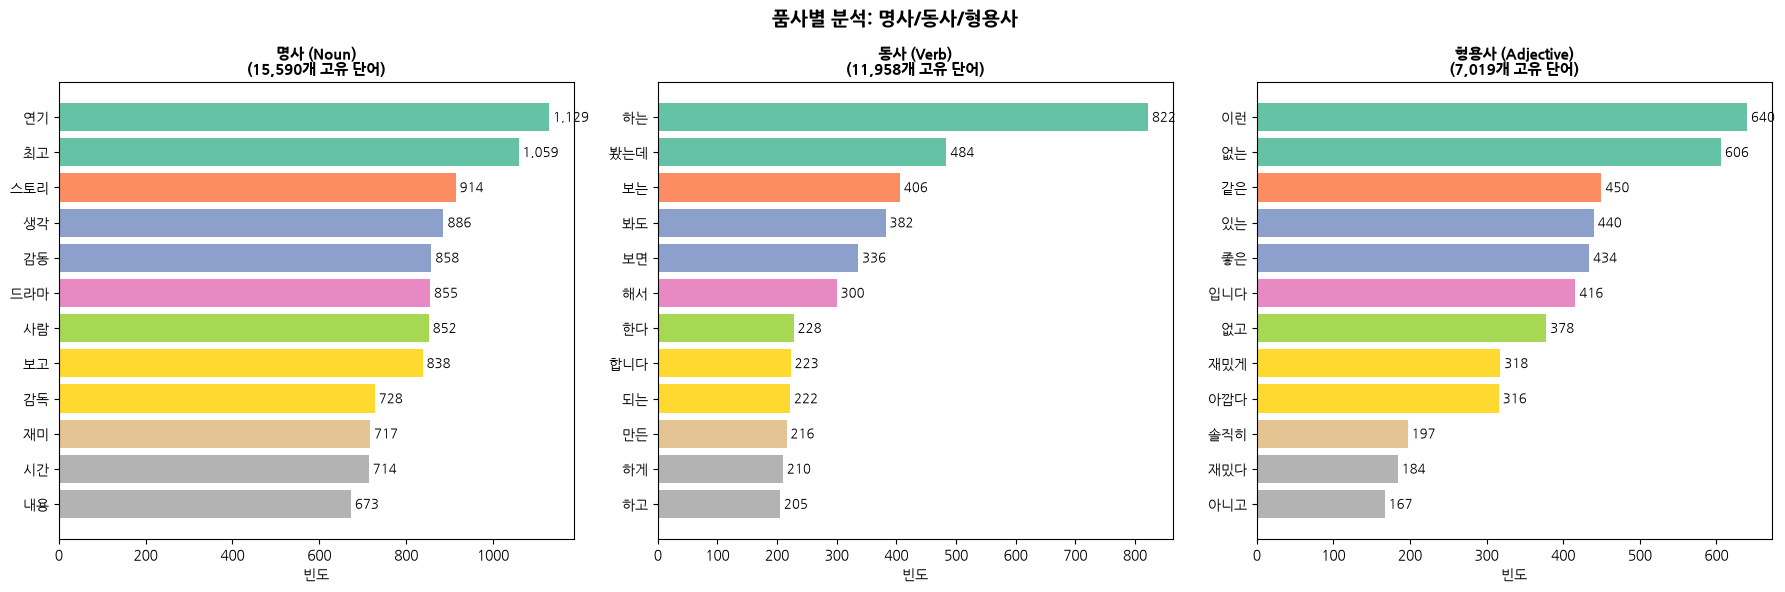


[품사별 통계]
명사: 15,590개 고유 단어, 106,689개 토큰
동사: 11,958개 고유 단어, 40,897개 토큰
형용사: 7,019개 고유 단어, 31,394개 토큰


In [27]:
# ==================== 고급 분석 3: 품사별 분석 ====================

print("[고급 분석 3] 품사별 분석 중...")

# 품사별 토큰 재집계 (필터 없이 원본으로)
noun_tokens = []
verb_tokens = []
adj_tokens = []

for sent in corpus:
    pos_tagged = okt.pos(sent)
    for morpheme, pos in pos_tagged:
        if pos == 'Noun' and morpheme not in IMPROVED_STOPWORDS and len(morpheme) >= 2:
            noun_tokens.append(morpheme)
        elif pos == 'Verb' and morpheme not in IMPROVED_STOPWORDS and len(morpheme) >= 2:
            verb_tokens.append(morpheme)
        elif pos == 'Adjective' and morpheme not in IMPROVED_STOPWORDS and len(morpheme) >= 2:
            adj_tokens.append(morpheme)

noun_counter = Counter(noun_tokens)
verb_counter = Counter(verb_tokens)
adj_counter = Counter(adj_tokens)

# 3분할 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('품사별 분석: 명사/동사/형용사', fontsize=14, fontweight='bold')

for ax, counter, title, pos_type in zip(
    axes,
    [noun_counter, verb_counter, adj_counter],
    ['명사 (Noun)', '동사 (Verb)', '형용사 (Adjective)'],
    ['noun', 'verb', 'adj']
):
    top_items = counter.most_common(12)
    words = [item[0] for item in top_items]
    freqs = [item[1] for item in top_items]
    
    bars = ax.barh(range(len(words)), freqs, color=plt.cm.Set2(np.linspace(0, 1, len(words))))
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)
    ax.set_xlabel('빈도', fontsize=10)
    ax.invert_yaxis()
    ax.set_title(f'{title}\n({len(counter):,}개 고유 단어)', fontsize=11, fontweight='bold')
    
    # 각 바에 수치 표시
    for i, (bar, freq) in enumerate(zip(bars, freqs)):
        ax.text(freq, i, f' {freq:,}', va='center', fontsize=9)

plt.tight_layout()
save_path = OUTPUT_DIR / "pos_analysis_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"✓ 저장됨: {save_path}")
plt.show()

print(f"\n[품사별 통계]")
print(f"명사: {len(noun_counter):,}개 고유 단어, {sum(noun_counter.values()):,}개 토큰")
print(f"동사: {len(verb_counter):,}개 고유 단어, {sum(verb_counter.values()):,}개 토큰")
print(f"형용사: {len(adj_counter):,}개 고유 단어, {sum(adj_counter.values()):,}개 토큰")


In [28]:
# ==================== 최종 요약 ====================

print()
print('=' * 70)
print('[실습 1] 한국어 영화 리뷰 분석 - 완료!')
print('=' * 70)

# 생성된 파일 목록 확인
import os
print('\n[생성된 파일 목록]')
for file in sorted(OUTPUT_DIR.glob('*')):
    print(f'  - {file.name}')

print('\n[학습 내용]')
contents = [
    '1. 정규표현식으로 한글 텍스트 전처리',
    '2. Okt 형태소 분석기를 이용한 단어 추출',
    '3. 불용어 필터를 통한 의미 있는 단어 선별',
    '4. Counter를 이용한 단어 빈도 계산',
    '5. BarPlot과 WordCloud를 활용한 시각화',
    '6. 통계 분석 및 분포 시각화',
    '7. 품사별 심화 분석',
]
for content in contents:
    print(f'  [O] {content}')

print('\n[다음 스텝 추천]')
print('  - 감성 분석(Sentiment Analysis) 추가 구현')
print('  - 다양한 형태소 분석기 비교 (MeCab, Kiwi 등)')
print('  - TF-IDF 기반 중요 단어 추출')

print('=' * 70)


[실습 1] 한국어 영화 리뷰 분석 - 완료!

[생성된 파일 목록]
  - advanced_analysis_grid.png
  - basic_top_tokens.txt
  - improved_top_tokens.txt
  - pos_analysis_comparison.png
  - 개선된_분석_BarPlot_+_WordCloud.png
  - 기본_분석_BarPlot_+_WordCloud.png

[학습 내용]
  [O] 1. 정규표현식으로 한글 텍스트 전처리
  [O] 2. Okt 형태소 분석기를 이용한 단어 추출
  [O] 3. 불용어 필터를 통한 의미 있는 단어 선별
  [O] 4. Counter를 이용한 단어 빈도 계산
  [O] 5. BarPlot과 WordCloud를 활용한 시각화
  [O] 6. 통계 분석 및 분포 시각화
  [O] 7. 품사별 심화 분석

[다음 스텝 추천]
  - 감성 분석(Sentiment Analysis) 추가 구현
  - 다양한 형태소 분석기 비교 (MeCab, Kiwi 등)
  - TF-IDF 기반 중요 단어 추출


---

# 🎓 학습 요약

| 단계 | 학습 내용 | 핵심 기술 |
|------|-----------|-----------|
| 1 | 데이터 로드 & 탐색 | pandas, 한글 인코딩 |
| 2 | 텍스트 전처리 | 정규표현식, 불용어 제거 |
| 3 | 형태소 분석 | KoNLPy (Okt/Komoran) |
| 4 | 시각화 | matplotlib, WordCloud |
| 5 | 감성 분석 | 긍정/부정 키워드 빈도 |

## 핵심 개념 정리

- **형태소 분석**: 한국어 문장을 의미 있는 최소 단위로 분리하는 기술. 영어와 달리 한국어는 띄어쓰기만으로 단어를 구분할 수 없어 필수적
- **불용어(Stopwords)**: "은", "는", "이", "가" 등 분석에 불필요한 단어를 제거하여 핵심 키워드만 추출
- **WordCloud**: 단어 빈도를 글자 크기로 시각화하여 텍스트의 핵심 주제를 한눈에 파악

## ✅ 실습 체크리스트

- [ ] 한국어 텍스트를 정규표현식으로 전처리할 수 있다
- [ ] KoNLPy로 형태소 분석을 수행할 수 있다
- [ ] WordCloud로 핵심 키워드를 시각화할 수 있다
- [ ] 단어 빈도 기반 감성 분석의 원리를 설명할 수 있다
- [ ] 불용어 제거가 왜 필요한지 설명할 수 있다

## 🚀 다음 단계

- **실습 2**: 이 전처리 기술을 활용하여 Seq2Seq 번역 모델의 입력 데이터를 구성합니다
- **심화**: TF-IDF, Word2Vec 등 더 정교한 텍스트 표현 방법 학습
- **응용**: 상품 리뷰, 뉴스 기사, SNS 등 다른 도메인 텍스트에 적용